# COURSE: A deep understanding of deep learning
## SECTION: CNN milestone projects
### LECTURE: Project 3: FMNIST
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [197]:
# import libraries 
import numpy as np 

import torch 
import torch.nn as nn
import torch.nn.functional as F

import torchvision

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

from torchsummary import summary

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

In [198]:
# use gpu 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [199]:
# Global variables 

BATCHSIZE = 64
LR = 0.001

# Load the data and inspect the data

In [200]:
train_data = torchvision.datasets.FashionMNIST(root='data/train/', train=True, download=True)
test_data = torchvision.datasets.FashionMNIST(root='data/test/', train=False, download=True)

In [201]:
print(train_data)
print(train_data.data.shape)
print(train_data.targets.shape)
print(train_data.classes)
print(train_data.targets[:10])
print(train_data.classes[train_data.targets[0]])

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data/train/
    Split: Train
torch.Size([60000, 28, 28])
torch.Size([60000])
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
tensor([9, 0, 0, 3, 0, 2, 7, 2, 5, 5])
Ankle boot


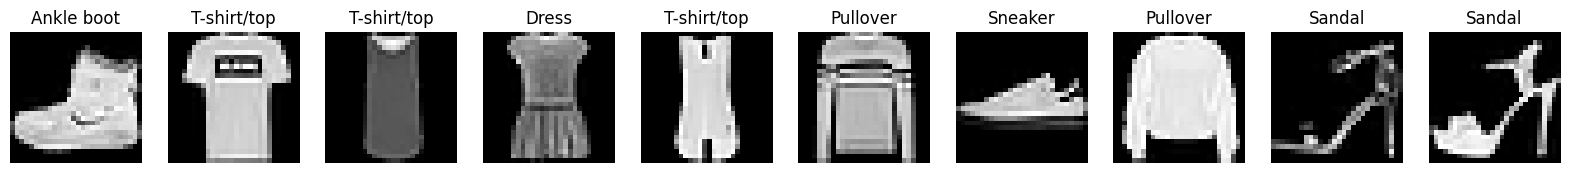

In [202]:
fig, ax = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    ax[i].imshow(train_data.data[i], cmap='gray')
    ax[i].set_title(train_data.classes[train_data.targets[i]])
    ax[i].axis('off')
plt.show()

# Order the data, normalize it and put it in loaders

In [203]:
valdata, testdata, vallabels, testlabels = train_test_split(test_data.data, test_data.targets, test_size=0.5, random_state=42)

train_data_tensor = torch.clone(train_data.data).detach().reshape(-1, 1, 28, 28) / 255.0
train_labels_tensor = torch.tensor(train_data.targets, dtype=torch.long)

val_data_tensor = torch.tensor(valdata, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0
val_labels_tensor = torch.tensor(vallabels, dtype=torch.long)

test_data_tensor = torch.tensor(testdata.data, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0
test_labels_tensor = torch.tensor(testlabels, dtype=torch.long)

train_dataset = TensorDataset(train_data_tensor, train_labels_tensor)
val_dataset = TensorDataset(val_data_tensor, val_labels_tensor)
test_dataset = TensorDataset(test_data_tensor, test_labels_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCHSIZE, shuffle=False, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=val_dataset.tensors[0].shape[0], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0], shuffle=False)

print(train_loader.dataset.tensors[0].shape)
print(train_loader.dataset.tensors[1].shape)
print(val_loader.dataset.tensors[0].shape)
print(val_loader.dataset.tensors[1].shape)
print(test_loader.dataset.tensors[0].shape)
print(test_loader.dataset.tensors[1].shape)

torch.Size([60000, 1, 28, 28])
torch.Size([60000])
torch.Size([5000, 1, 28, 28])
torch.Size([5000])
torch.Size([5000, 1, 28, 28])
torch.Size([5000])


/tmp/ipykernel_5587/303679830.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_labels_tensor = torch.tensor(train_data.targets, dtype=torch.long)
/tmp/ipykernel_5587/303679830.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_data_tensor = torch.tensor(valdata, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0
/tmp/ipykernel_5587/303679830.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_labels_tensor = torch.tensor(vallabels, dtype=torch.long)
/tmp/ipykernel_5587/303679830.py:9: UserWarning: To copy construct from

# Create the model

In [212]:
def makeTheNet():
    class fmnistnet(nn.Module):
        def __init__(self):
            super().__init__()

            self.ccn1 = nn.Sequential(
                nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(16),
                nn.MaxPool2d(2),
                nn.LeakyReLU(),
                nn.Dropout(0.1)
                # output: floor((28+2*1-3)/1) + 1 = 28 / 2 = 14
            )

            self.ccn2 = nn.Sequential(
                nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(32),
                nn.MaxPool2d(2),
                nn.LeakyReLU(),
                nn.Dropout(0.1)
                # output: floor((14+2*1-3)/1) + 1 = 14 / 2 = 7
            )

            self.ccn3 = nn.Sequential(
                nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(64),
                nn.MaxPool2d(2),
                nn.LeakyReLU(),
                nn.Dropout(0.1)
                # output: floor((7+2*1-3)/1) + 1 = 7 / 2 = 3
            )

            self.fc1 = nn.Sequential(
                nn.Linear(64*3*3, 256),
                nn.BatchNorm1d(256),
                nn.LeakyReLU(),
                nn.Dropout(0.3)
            )

            self.fc2 = nn.Sequential(
                nn.Linear(256, 128),
                nn.BatchNorm1d(128),
                nn.LeakyReLU(),
                nn.Dropout(0.3)
            )

            self.fc3 = nn.Sequential(
                nn.Linear(128, 10), 
                # nn.Softmax(dim=1) # Not needed as we will use CrossEntropyLoss
            )

        def forward(self, x):
            self.ccn1_out = self.ccn1(x)
            self.ccn2_out = self.ccn2(self.ccn1_out)
            self.ccn3_out = self.ccn3(self.ccn2_out)
            
            nUnits = self.ccn3_out.shape.numel()/self.ccn3_out.shape[0] # number of features per sample in the batch (numelems/batchsize)
            ccn3_output = self.ccn3_out.view(-1, int(nUnits)) # -1 gets the batchsize automatically, and nUnits is the number of features per sample

            self.fc1_out = self.fc1(ccn3_output)
            self.fc2_out = self.fc2(self.fc1_out)
            self.output = self.fc3(self.fc2_out)

            return self.output
        
    net = fmnistnet()

    lossfun = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(net.parameters(), lr=LR)

    return net, lossfun, optimizer

# Test the model

In [213]:
net, lossfun, optimizer = makeTheNet()
net.to(device)  # Move the model to the same device as the input tensor

X, y = next(iter(train_loader))
X, y = X.to(device), y.to(device)  # Move input and labels to the same device
yHat = net(X)

summary(net, (1, 28, 28), device=str(device))  # Ensure summary uses the correct device

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             160
       BatchNorm2d-2           [-1, 16, 28, 28]              32
         MaxPool2d-3           [-1, 16, 14, 14]               0
         LeakyReLU-4           [-1, 16, 14, 14]               0
           Dropout-5           [-1, 16, 14, 14]               0
            Conv2d-6           [-1, 32, 14, 14]           4,640
       BatchNorm2d-7           [-1, 32, 14, 14]              64
         MaxPool2d-8             [-1, 32, 7, 7]               0
         LeakyReLU-9             [-1, 32, 7, 7]               0
          Dropout-10             [-1, 32, 7, 7]               0
           Conv2d-11             [-1, 64, 7, 7]          18,496
      BatchNorm2d-12             [-1, 64, 7, 7]             128
        MaxPool2d-13             [-1, 64, 3, 3]               0
        LeakyReLU-14             [-1, 6

# Create a function that trains the model

In [214]:
def function2trainTheModel(epochs=10, val=False):
    epochs = epochs

    net, lossfun, optimizer = makeTheNet()

    net.to(device)

    trainLoss = torch.zeros(epochs)
    valLoss = torch.zeros(epochs)
    testLoss = torch.zeros(epochs)

    trainAcc = torch.zeros(epochs)
    valAcc = torch.zeros(epochs)
    testAcc = torch.zeros(epochs)

    for epoch in range(epochs):
        net.train()

        batchLoss = []
        batchAcc = []

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            yHat = net(X)
            loss = lossfun(yHat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchLoss.append(loss.item())
            batchAcc.append((yHat.argmax(dim=1) == y).float().mean().item())

        trainLoss[epoch] = np.mean(batchLoss)
        trainAcc[epoch] = np.mean(batchAcc)

        net.eval()
        x, y = next(iter(val_loader))
        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            yHat = net(x)
            loss = lossfun(yHat, y)

        valLoss[epoch] = loss.item()
        valAcc[epoch] = (yHat.argmax(dim=1) == y).float().mean().item()

        if val:
            x, y = next(iter(test_loader))
            x, y = x.to(device), y.to(device)

            with torch.no_grad():
                yHat = net(x)
                loss = lossfun(yHat, y)

            testLoss[epoch] = loss.item()
            testAcc[epoch] = (yHat.argmax(dim=1) == y).float().mean().item()

    return net, trainLoss, valLoss, testLoss, trainAcc, valAcc, testAcc

# Test the training function

In [207]:
net, trainLoss, valLoss, testLoss, trainAcc, valAcc, testAcc = function2trainTheModel(epochs=2, val=False)

# Train the model

In [215]:
net, trainLoss, valLoss, testLoss, trainAcc, valAcc, testAcc = function2trainTheModel(epochs=15, val=False)

# Graph the results

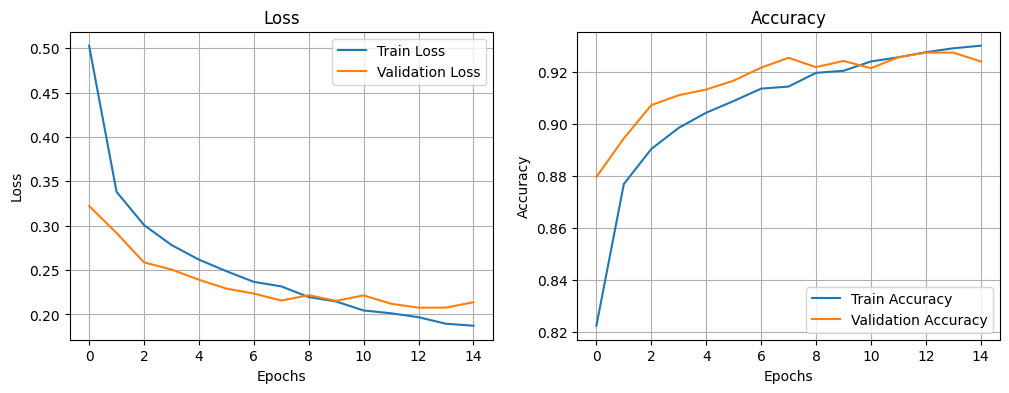

In [216]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(trainLoss, label='Train Loss')
axs[0].plot(valLoss, label='Validation Loss')
axs[0].set_title('Loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid()

axs[1].plot(trainAcc, label='Train Accuracy')
axs[1].plot(valAcc, label='Validation Accuracy')
axs[1].set_title('Accuracy')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid()

plt.show()

# Train the final model

In [217]:
net, trainLoss, valLoss, testLoss, trainAcc, valAcc, testAcc = function2trainTheModel(epochs=15, val=True)

# Graph the final model

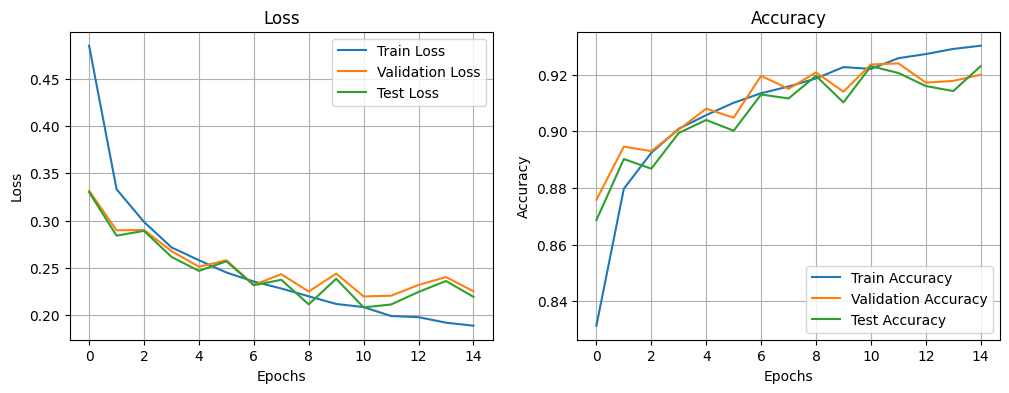

In [218]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(trainLoss, label='Train Loss')
axs[0].plot(valLoss, label='Validation Loss')
axs[0].plot(testLoss, label='Test Loss')
axs[0].set_title('Loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid()

axs[1].plot(trainAcc, label='Train Accuracy')
axs[1].plot(valAcc, label='Validation Accuracy')
axs[1].plot(testAcc, label='Test Accuracy')
axs[1].set_title('Accuracy')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid()

plt.show()